In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Brownian Motion:

$ W(t_{i+1})=W(t_i)+\sqrt{t_{i+1}-t_i}Z_{i+1} $

$ Z_{i+1} $ is the normally distributed sample at time $ t_{i+1} $

We shall utilize a vectorized approach to generate k paths concurrently.

Resource: [Brownian Motion Tutorial](https://www.quantstart.com/articles/brownian-motion-simulation-with-python/)

### Intuition: What Is Brownian Motion?

Brownian motion (also called a **Wiener process**) is the continuous-time limit of a symmetric random walk. Imagine a particle being bumped randomly left and right at discrete time steps — as you shrink the step size to zero while scaling the displacement by √dt, the path converges to standard Brownian motion.

**Four defining properties of W(t):**
1. **W(0) = 0** — starts at the origin
2. **Independent increments** — W(t) − W(s) is independent of the history before time s
3. **Stationary Gaussian increments** — W(t) − W(s) ~ N(0, t−s) for any s < t
4. **Continuous paths** — no jumps (though paths are *nowhere differentiable* — infinitely jagged)

**The key insight that breaks ordinary calculus:**

In ordinary calculus, (dx)² → 0 as dx → 0. For Brownian motion, **(dW)² = dt** — second-order terms survive because the variance of each increment is exactly dt. This means when you Taylor-expand a function of a stochastic process, you cannot drop the second-order term. This is where the **Itô correction** comes from.

Concretely: if you try to write dW² you get dt exactly (not "approximately") — this is called the **quadratic variation** of Brownian motion. It's what makes stochastic calculus different from ordinary calculus.

The 50 paths below are 50 independent realizations of W(t) on [0, 1]. Notice the fan shape — paths spread out like √t, because Var[W(t)] = t.

In [3]:
rng = np.random.default_rng(7777)

paths = 50
points = 2000

mu, sigma = 0.0, 1.0

Z = rng.normal(mu, sigma, (paths, points))

interval = [0.0, 1.0]

dt = (interval[1] - interval[0]) / (points-1)

t_axis = np.linspace(interval[0], interval[1], points)

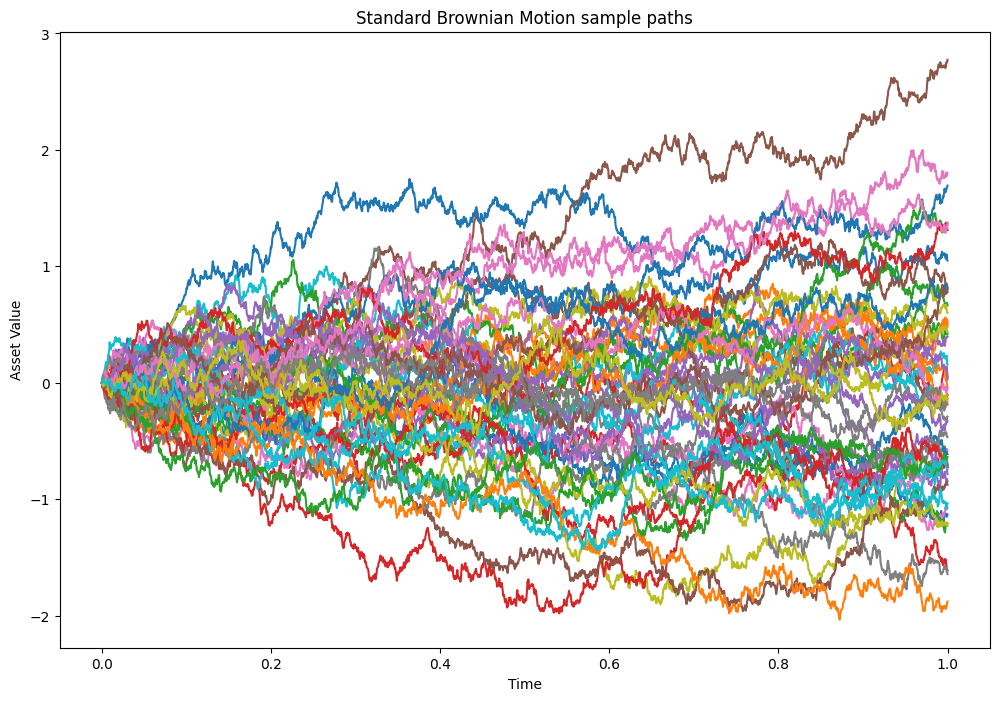

In [4]:
W = np.zeros((paths, points))
for i in range(points-1):
    real_idx = i + 1
    W[:, real_idx] = W[:, real_idx - 1] + np.sqrt(dt) * Z[:, i]
    
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, W[path, :])
    
ax.set_title("Standard Brownian Motion sample paths")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")

plt.show()

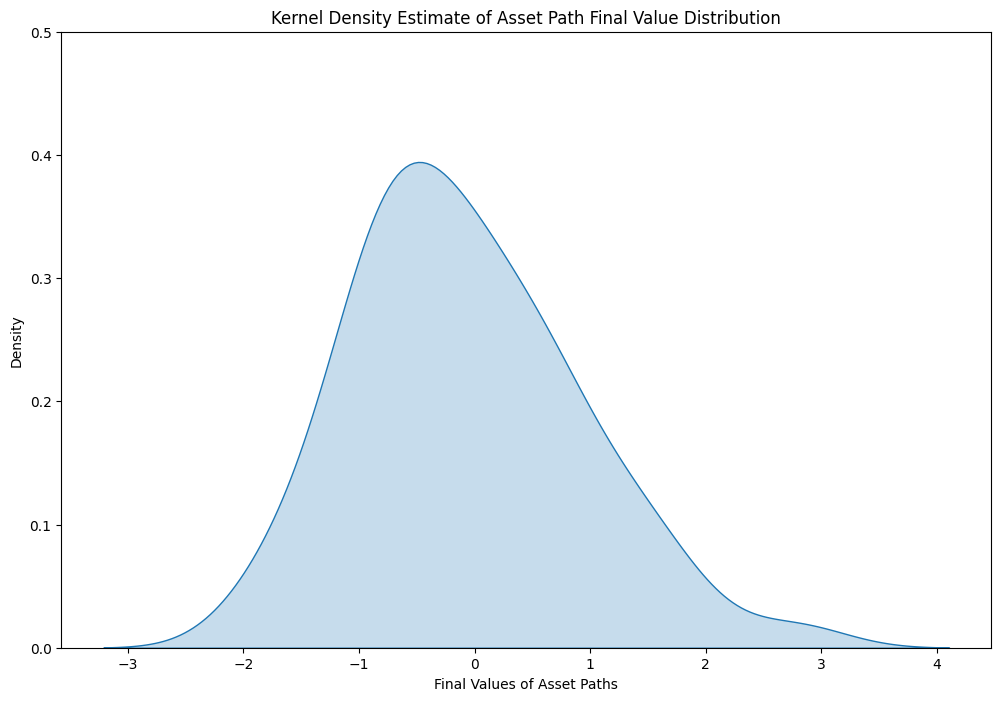

In [5]:
final_values = pd.DataFrame({'final_values': W[:, -1]})

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sns.kdeplot(data=final_values, x='final_values', fill=True, ax=ax)
ax.set_title("Kernel Density Estimate of Asset Path Final Value Distribution")
ax.set_ylim(0.0, 0.5)
ax.set_xlabel("Final Values of Asset Paths")
plt.show()

In [6]:
print(final_values.mean())
print(final_values.std())

final_values   -0.07538
dtype: float64
final_values    0.968692
dtype: float64


### Why Monte Carlo Is Genuinely Powerful (And Where Your Skepticism Is Right)

You're right that for **standard BM with constant μ and σ**, Monte Carlo just samples a distribution you already know analytically:
- E[W(T)] = 0, Var[W(T)] = T — no simulation needed
- Running MC here just confirms what the math already tells you

**But MC becomes indispensable when:**

**1. Path Dependency** — the payoff depends on the *entire path*, not just the terminal value.
- **Callable bonds**: the issuer calls when rates fall below the coupon rate. You need to know whether rates crossed a threshold at *every point in time*. There is no closed-form formula — you simulate the path.
- **Mortgage-backed securities (MBS)**: homeowner prepayment behavior depends on the full rate history (e.g., refinancing incentive builds up over time).
- **Barrier options on rates**: a knock-out event can only be detected by simulating the full trajectory.

**2. No Closed-Form Solution** — most realistic models don't have one.
- Multi-factor term structure models (e.g., G2++, LMM, HJM with general vol)
- Stochastic volatility + stochastic rates simultaneously (Heston + Hull-White)
- Credit risk + market risk combined (CVA / DVA / XVA calculations)

**3. American / Bermudan Exercise** — when can the holder optimally *stop*? The Longstaff-Schwartz algorithm (2001) solves this: simulate paths forward, then regress continuation values backward. Entirely MC-based.

**4. Portfolio-Level Distributions** — simulating 50 correlated bonds simultaneously to get tail risk (VaR, CVaR). Analytical methods break down with correlations and non-linearities.

**Bottom line**: MC doesn't strengthen claims about mean and vol for simple models — you're right. Its power is generating **distributions of outcomes for complex, path-dependent instruments where analytical solutions either don't exist or are intractable**. In fixed income, this is the standard tool for any bond with embedded optionality.

## Constant Drift and Vol Brownian Motion

$ X(t_{i+1})=X(t_i)+\mu(t_{i+1}-t_i)+\sigma\sqrt{t_{i+1}-t_i}Z_{i+1} $

### Arithmetic Brownian Motion (ABM): Properties and Limitations

X(t) = X(0) + μt + σW(t) is called **Arithmetic Brownian Motion**. It adds a deterministic linear drift on top of random noise.

**Key stats:**
- **E[X(T)] = X(0) + μT** — expected value follows a straight line
- **Var[X(T)] = σ²T** — variance grows linearly in time
- **X(t) can go negative** — this is fine for spreads or P&L, but wrong for asset *prices*

**In fixed income, ABM is used for:**
- Daily P&L of a bond portfolio (symmetric around zero makes sense)
- Modeling *changes* in credit spreads (not spread levels)
- Rate changes over short windows, before mean reversion dominates
- The **Vasicek model** is essentially ABM with mean reversion added: dr = κ(θ − r)dt + σ dW

The simulation below shows how increasing μ from 0.0 → 5.0 bends all paths upward with a spread of σ around the mean line X(0) + μt. Notice: the drift is deterministic and perfectly smooth; all randomness comes from σW(t).

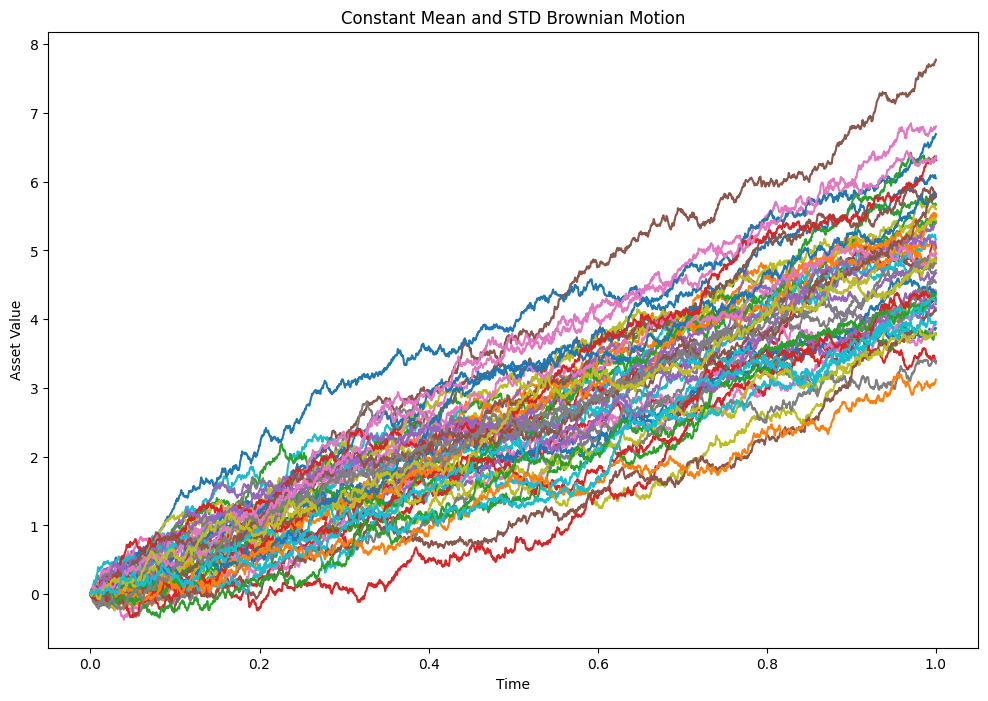

In [7]:
mu_c, sigma_c = 5.0, 2.0

X = np.zeros((paths, points))
for i in range(points - 1):
    real_idx = i + 1
    X[:, real_idx] = X[:, real_idx - 1] + mu_c*dt + sigma*np.sqrt(dt)*Z[:,i]
    
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, X[path, :])
    
ax.set_title("Constant Mean and STD Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")

plt.show()

## Geometric Brownian Motion (GBM) and Itô's Lemma

ABM has a fatal flaw for asset prices: **prices can go negative**. We fix this by modeling the *log return* as Brownian — not the price itself.

**The GBM SDE:** dS = μS dt + σS dW

This says: the *proportional* change in price dS/S has constant drift μ and constant volatility σ. It's scale-invariant — whether the stock is at $10 or $1000, a 1% move behaves the same way.

**Solving via Itô's Lemma** — apply f(S) = ln(S):

$$S(t) = S(0)\exp\!\left[\left(\mu - \tfrac{\sigma^2}{2}\right)t + \sigma W(t)\right]$$

**Why the Itô correction (−σ²/2)?**

Itô's Lemma is the stochastic chain rule. If dX = a dt + b dW, and f(X, t):

$$df = \left(\frac{\partial f}{\partial t} + a\frac{\partial f}{\partial X} + \frac{1}{2}b^2\frac{\partial^2 f}{\partial X^2}\right)dt + b\frac{\partial f}{\partial X}dW$$

The **½b²∂²f/∂X²** term is pure Itô — it comes from (dW)² = dt surviving the Taylor expansion. In ordinary calculus this term is zero. Apply this with f = ln(S), a = μS, b = σS:

$$d(\ln S) = \left(\mu - \tfrac{\sigma^2}{2}\right)dt + \sigma\, dW$$

Integrate both sides: you get the GBM solution above. The −σ²/2 correction is not optional — forgetting it is a classic mistake that overestimates the expected price level.

**Key insight on mean vs. median:**
- **Arithmetic mean of S(T)**: S(0)e^(μT) — pulled up by the right tail of the log-normal distribution
- **Median of S(T)**: S(0)e^((μ−σ²/2)T) — the "most likely" path, reduced by the Itô correction
- The gap between them widens as σ increases — this is Jensen's inequality in action

In [ ]:
# Geometric Brownian Motion: S(t) = S(0) * exp((mu - sigma²/2)*t + sigma*W(t))
S0 = 100.0
mu_gbm = 0.08       # 8% expected annual return
sigma_gbm = 0.20    # 20% annual volatility

T_gbm = 1.0
rng2 = np.random.default_rng(42)
Z_gbm = rng2.normal(0, 1, (paths, points))

t_gbm = np.linspace(0, T_gbm, points)
dt_gbm = T_gbm / (points - 1)

W_gbm = np.zeros((paths, points))
for i in range(points - 1):
    W_gbm[:, i+1] = W_gbm[:, i] + np.sqrt(dt_gbm) * Z_gbm[:, i]

# Exact solution — no discretization error
S = S0 * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * t_gbm + sigma_gbm * W_gbm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: sample paths + mean/median
for path in range(paths):
    axes[0].plot(t_gbm, S[path, :], alpha=0.45, linewidth=0.8)
axes[0].plot(t_gbm, S0 * np.exp(mu_gbm * t_gbm), 'k--', linewidth=2, label=f'E[S(t)] = S₀·e^(μt)  [arithmetic mean]')
axes[0].plot(t_gbm, S0 * np.exp((mu_gbm - 0.5*sigma_gbm**2) * t_gbm), 'r--', linewidth=2, label='Median path = S₀·e^((μ−σ²/2)t)')
axes[0].set_title("Geometric Brownian Motion")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Price ($)")
axes[0].legend(fontsize=9)

# Right: terminal distribution (use 5000 paths for smooth histogram)
rng3 = np.random.default_rng(99)
terminal_large = S0 * np.exp(
    (mu_gbm - 0.5*sigma_gbm**2)*T_gbm + sigma_gbm*np.sqrt(T_gbm)*rng3.normal(0, 1, 5000)
)
axes[1].hist(terminal_large, bins=60, edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(np.mean(terminal_large), color='black', linestyle='--', linewidth=2,
                label=f'Mean ≈ {np.mean(terminal_large):.1f}  (theory: {S0*np.exp(mu_gbm):.1f})')
axes[1].axvline(np.median(terminal_large), color='red', linestyle='--', linewidth=2,
                label=f'Median ≈ {np.median(terminal_large):.1f}  (theory: {S0*np.exp(mu_gbm-0.5*sigma_gbm**2):.1f})')
axes[1].set_title("Terminal Price Distribution S(T=1) — Log-Normal, 5000 paths")
axes[1].set_xlabel("S(T)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Theoretical E[S(T)]:  {S0 * np.exp(mu_gbm * T_gbm):.2f}")
print(f"Simulated mean:        {np.mean(terminal_large):.2f}")
print(f"Median / most likely:  {S0 * np.exp((mu_gbm - 0.5*sigma_gbm**2)*T_gbm):.2f}  ← Itô correction shifts this down from mean")

## Short Rate Models: Mean Reversion for Interest Rates

Unlike equity prices, **interest rates cannot follow GBM**:
1. Rates don't grow exponentially — there are economic forces pulling them toward equilibrium
2. Extreme rates are transient — central banks and market forces keep rates in a range
3. A 10% rate with 20% vol would reach 100% or 0% quickly — empirically nonsensical

**The Vasicek Model (1977):** $dr = \kappa(\theta - r)\,dt + \sigma\,dW$

| Parameter | Name | Intuition |
|-----------|------|-----------|
| κ | Mean reversion speed | How fast rates snap back. κ=0.5 → half-life of ~1.4 years |
| θ | Long-run equilibrium | Where rates are attracted. Think "neutral rate" |
| σ | Rate volatility | Annual vol of rate changes |

**Analytical solution:**
$$r(t) = r(0)e^{-\kappa t} + \theta(1 - e^{-\kappa t}) + \sigma e^{-\kappa t}\int_0^t e^{\kappa s}\,dW(s)$$

- As t → ∞: E[r(t)] → θ, Var[r(t)] → σ²/2κ (stationary distribution)
- **Flaw**: r(t) can go negative. Was theoretical concern pre-2008; became reality in Europe/Japan

**The CIR Model (Cox-Ingersoll-Ross, 1985):** $dr = \kappa(\theta - r)\,dt + \sigma\sqrt{r}\,dW$

- The √r term: vol shrinks as rates approach zero → rates can't cross zero (if 2κθ > σ²)
- Stays non-negative, but is no longer Gaussian — harder to work with analytically
- Still has analytical bond prices (just more complex)

**Why this matters for bond pricing:**

The price of a zero-coupon bond P(t, T) under any short rate model is:
$$P(t, T) = E^Q\!\left[\exp\!\left(-\int_t^T r(s)\,ds\right)\Bigg|\,\mathcal{F}_t\right]$$

The exponential of a path integral over r(s) is exactly why we need either:
- **Monte Carlo**: simulate many rate paths → average the discounted payoffs (general, flexible)
- **PDE methods**: derive a PDE for P(r, t) via Itô + Feynman-Kac, then solve numerically or analytically

For Vasicek and CIR, the analytical solution is: P(t,T) = A(t,T)·exp(−B(t,T)·r(t))
where A and B are deterministic functions of κ, θ, σ and (T−t). This is the **affine term structure** property.

In [ ]:
# Vasicek Short Rate Model: dr = κ(θ - r)dt + σ dW
kappa   = 0.5      # mean reversion speed
theta   = 0.04     # long-run equilibrium rate (4%)
sigma_r = 0.015    # rate volatility (1.5%)
r0      = 0.055    # starting rate (5.5% — roughly current environment)

T_r = 5.0
points_r = 1000
dt_r = T_r / (points_r - 1)
t_r  = np.linspace(0, T_r, points_r)

rng_v = np.random.default_rng(2024)
Z_v   = rng_v.normal(0, 1, (paths, points_r))

r_paths = np.zeros((paths, points_r))
r_paths[:, 0] = r0
for i in range(points_r - 1):
    dr = kappa * (theta - r_paths[:, i]) * dt_r + sigma_r * np.sqrt(dt_r) * Z_v[:, i]
    r_paths[:, i+1] = r_paths[:, i] + dr

# Theoretical mean and ±2σ band
r_mean_th = r0 * np.exp(-kappa * t_r) + theta * (1 - np.exp(-kappa * t_r))
r_var_th  = (sigma_r**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * t_r))
r_std_th  = np.sqrt(r_var_th)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for path in range(paths):
    axes[0].plot(t_r, r_paths[path, :] * 100, alpha=0.35, linewidth=0.8)
axes[0].plot(t_r, r_mean_th * 100, 'k--', linewidth=2.2, label=f'E[r(t)] → θ = {theta*100:.1f}%')
axes[0].fill_between(t_r,
    (r_mean_th - 2*r_std_th)*100, (r_mean_th + 2*r_std_th)*100,
    alpha=0.15, color='gray', label='±2σ band')
axes[0].axhline(theta * 100, color='red', linewidth=1.5, linestyle=':', label=f'Long-run mean θ = {theta*100:.1f}%')
axes[0].set_title(f"Vasicek Rate Paths  (κ={kappa}, θ={theta*100:.0f}%, σ={sigma_r*100:.1f}%)")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Short Rate (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rate distribution at 1yr and 5yr horizons
idx_1y = points_r // 5
axes[1].hist(r_paths[:, idx_1y] * 100, bins=15, alpha=0.6, density=True, label=f'T={T_r/5:.0f}yr distribution')
axes[1].hist(r_paths[:, -1]    * 100, bins=15, alpha=0.6, density=True, label=f'T={T_r:.0f}yr distribution')
axes[1].axvline(theta * 100, color='red', linewidth=2, linestyle='--', label=f'Long-run mean = {theta*100:.0f}%')
axes[1].set_title("Rate Distribution at Different Horizons")
axes[1].set_xlabel("Rate (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting rate r(0):          {r0*100:.2f}%")
print(f"Long-run equilibrium θ:       {theta*100:.2f}%")
print(f"E[r(T={T_r}yr)] theory:        {r_mean_th[-1]*100:.2f}%")
print(f"E[r(T={T_r}yr)] simulated:     {r_paths[:,-1].mean()*100:.2f}%")
print(f"Std[r(T={T_r}yr)] theory:       {r_std_th[-1]*100:.2f}%")
print(f"Std[r(T={T_r}yr)] simulated:    {r_paths[:,-1].std()*100:.2f}%")
print(f"\nNote: paths can go negative — this is the Vasicek model's known flaw.")
print(f"Negative paths this sim: {(r_paths.min(axis=1) < 0).sum()} out of {paths}")

## Learning Roadmap: Fixed Income Quant

### Where You Are
- ✓ Standard Brownian Motion — continuous random walk, key properties, quadratic variation
- ✓ Why (dW)² = dt — the fundamental difference from ordinary calculus
- ✓ Arithmetic BM with drift (ABM) — E[X(T)] = μT, Var = σ²T, can go negative
- ✓ Geometric BM (GBM) — the Black-Scholes world, log-normal prices, always positive
- ✓ Itô's Lemma — the stochastic chain rule and why the −σ²/2 correction exists
- ✓ Vasicek / CIR short rate models — mean-reverting rates, analytical bond prices

---

### Next Steps (in order)

**Level 1 — Build intuition with models you can run right now:**
1. **Bond pricing under Vasicek** — use your rate paths to compute P(0,T) = E[exp(−∫r dt)] numerically and verify against the closed-form formula
2. **Yield curve from Vasicek** — plot the model-implied yield curve at different κ, θ, σ and see how each parameter affects the shape (level, slope, curvature)
3. **Duration and convexity numerically** — compute dP/dr and d²P/dr² from your simulated price distribution

**Level 2 — Multi-factor and calibrated models:**
4. **Hull-White model** — Vasicek with time-varying θ(t); calibrate exactly to today's observed yield curve
5. **G2++ model** — two correlated Vasicek factors r(t) = x(t) + y(t) + φ(t); produces realistic humped vol structures and better fit to swaption vol surfaces
6. **Nelson-Siegel** — purely empirical curve model: y(τ) = β₀ + β₁·(1−e^(−τ/λ))/(τ/λ) + β₂·(...); widely used by central banks for yield curve fitting

**Level 3 — Pricing optionality (where MC becomes essential):**
7. **Callable bond pricing** — simulate Vasicek/HW rate paths, apply call rule at each step (call if rate < coupon), discount cash flows back
8. **Cap/floor pricing** — Black's formula for caplets as a benchmark, then verify with MC under HW
9. **Swaption pricing** — Black's formula vs. HJM MC; understand the vol surface
10. **HJM framework** — model the entire forward rate curve dF(t,T) = α dt + σ dW; Vasicek/HW are special cases

**Level 4 — Credit and portfolio:**
11. **Hazard rate / intensity models** — credit spread = λ(t) · LGD; price CDS and corporate bonds
12. **Correlated rate + credit MC** — simulate both simultaneously; measure CVA on a bond portfolio
13. **Libor Market Model (LMM)** — direct simulation of forward rates for cap/floor/swaption pricing

---

### Key Texts (in order of difficulty)
| Book | What It Teaches |
|------|----------------|
| Hull — *Options, Futures, and Other Derivatives* | Best intro to stochastic calculus for finance; clear, practitioner-friendly |
| Tuckman & Serrat — *Fixed Income Securities* | Deep fixed income intuition: duration, convexity, term structure, MBS |
| Brigo & Mercurio — *Interest Rate Models* | The standard rigorous reference; covers everything from Vasicek to LMM |
| Shreve — *Stochastic Calculus for Finance II* | The math done properly: measure theory, Girsanov, risk-neutral pricing |
| Rebonato — *Volatility and Correlation* | Advanced: vol surfaces, LMM calibration, smile dynamics |